In [9]:
import numpy as np
import matplotlib.pyplot as plt
import os

from scipy import constants
from scipy.signal import find_peaks
from scipy.optimize import curve_fit

In [10]:
from labmate.acquisition_notebook import AcquisitionAnalysisManager

In [11]:
from utils.plot_style import set_plot_style 
set_plot_style()

# Birefringence plot

In [4]:
path_folder_data = r"./data/oscilloscope/scope_acq_2026_05_12__07_45_12/"
folder_data_files = os.listdir(path_folder_data)
print(folder_data_files)

['oscilloscope_trace', 'temp.json']


In [5]:
# fine data scan :
name_exp = 'oscilloscope_trace'
name = "2026_05_12__08_05_23__oscilloscope_trace.h5"
full_path = os.path.join(path_folder_data, name_exp, name)
aqm = AcquisitionAnalysisManager( os.path.join(path_folder_data, name_exp))
aqm.analysis_cell(filename=full_path)

print(aqm.data)

INFO:2026_05_12__08_05_23__oscilloscope_trace


AnalysisData (rw) (not saved): 
 {
    "CH1_pt_off" (r): "0.000e+00 (type : float64)",
    "CH1_x" (r): "shape: (125000,) (type: ndarray)",
    "CH1_xincr" (r): "8.000e-08 (type : float64)",
    "CH1_xzero" (r): "7.280e-03 (type : float64)",
    "CH1_y" (r): "shape: (125000,) (type: ndarray)",
    "CH1_y_raw" (r): "shape: (125000,) (type: ndarray)",
    "CH1_ymult" (r): "2.000e-02 (type : float64)",
    "CH1_yoff" (r): "-90.000 (type : float64)",
    "CH1_yzero" (r): "0.000e+00 (type : float64)",
    "CH2_pt_off" (r): "0.000e+00 (type : float64)",
    "CH2_x" (r): "shape: (125000,) (type: ndarray)",
    "CH2_xincr" (r): "8.000e-08 (type : float64)",
    "CH2_xzero" (r): "7.280e-03 (type : float64)",
    "CH2_y" (r): "shape: (125000,) (type: ndarray)",
    "CH2_y_raw" (r): "shape: (125000,) (type: ndarray)",
    "CH2_ymult" (r): "2.000e-02 (type : float64)",
    "CH2_yoff" (r): "-100.000 (type : float64)",
    "CH2_yzero" (r): "0.000e+00 (type : float64)",
    "CH3_pt_off" (r): "0.000e+

In [32]:
# List all files in the folder
name_exp = 'oscilloscope_trace'
folder_data_files = os.listdir(path_folder_data + '/' + name_exp)
print(folder_data_files)

['2026_05_12__07_59_52__oscilloscope_trace.h5', '2026_05_12__08_05_23__oscilloscope_trace.h5', '2026_05_12__09_00_53__oscilloscope_trace.h5', '2026_05_12__09_09_43__oscilloscope_trace.h5', '2026_05_12__09_10_28__oscilloscope_trace.h5', '2026_05_12__09_18_57__oscilloscope_trace.h5', '2026_05_12__09_19_21__oscilloscope_trace.h5', '2026_05_12__09_19_44__oscilloscope_trace.h5', '2026_05_12__09_20_03__oscilloscope_trace.h5', '2026_05_12__09_38_35__oscilloscope_trace.h5', '2026_05_12__09_39_06__oscilloscope_trace.h5', '2026_05_12__09_41_35__oscilloscope_trace.h5', '2026_05_12__09_47_39__oscilloscope_trace.h5', '2026_05_12__09_48_07__oscilloscope_trace.h5', '2026_05_12__09_48_41__oscilloscope_trace.h5', '2026_05_12__09_49_16__oscilloscope_trace.h5']


In [31]:
x_list = []
y_list = []
ch_list = []
file_list = []

aqm = AcquisitionAnalysisManager(os.path.join(path_folder_data, name_exp))

# name = "2026_05_12__08_05_23__oscilloscope_trace.h5"
name = "2026_05_12__09_00_53__oscilloscope_trace.h5"
full_path = os.path.join(path_folder_data, name_exp, name)
aqm.analysis_cell(filename=full_path)

data = aqm.data

# find channels present in this file
channels = []
for ch in ["CH1", "CH2", "CH3", "CH4"]:
    if f"{ch}_x" in data and f"{ch}_y" in data:
        channels.append(ch)

for ch in channels:
    x_list.append(data[f"{ch}_x"])
    y_list.append(data[f"{ch}_y"])
    ch_list.append(ch)
    file_list.append(name)

    print(f"Loaded {name} / {ch}")

INFO:2026_05_12__09_00_53__oscilloscope_trace


Loaded 2026_05_12__09_00_53__oscilloscope_trace.h5 / CH1
Loaded 2026_05_12__09_00_53__oscilloscope_trace.h5 / CH2


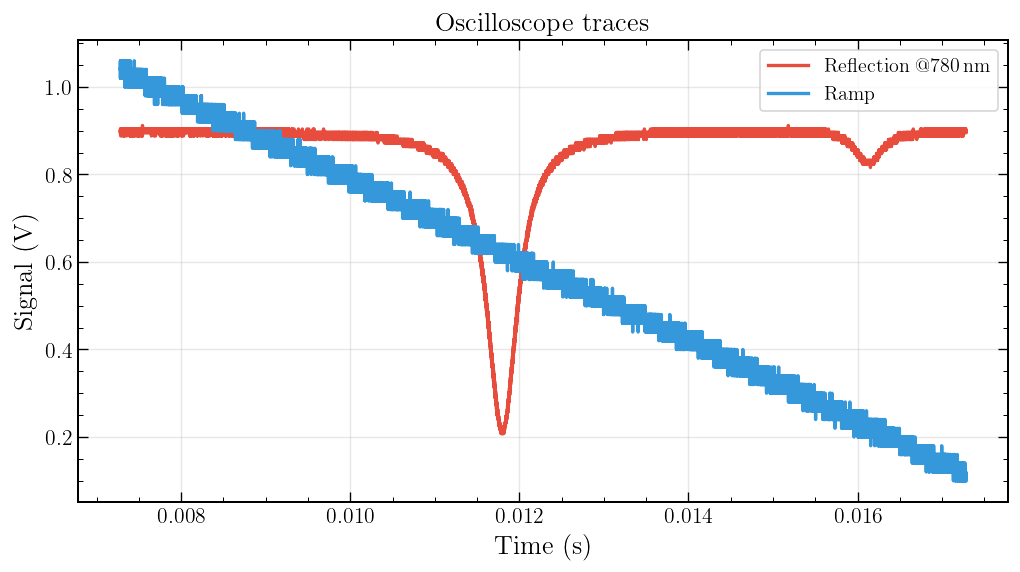

In [8]:
# custom labels
label_map = {
    "CH1": r"Reflection $@780\,\mathrm{nm}$",
    "CH2": r"Ramp",
    "CH3": r"Transmission $@390\,\mathrm{nm}$",
}

# Plot
set_plot_style()
fig, ax = plt.subplots(figsize=(10,5))

for x, y, ch in zip(x_list, y_list, ch_list):

    # fallback to channel name if not defined
    label = label_map.get(ch, ch)

    ax.plot(x, y, label=label)

ax.set_xlabel("Time (s)")
ax.set_ylabel("Signal (V)")
ax.set_title("Oscilloscope traces")
ax.grid()

legend = ax.legend(loc="upper right", frameon=True)
legend.get_frame().set_facecolor('white')

plt.show()

INFO:2026_05_12__09_18_57__oscilloscope_trace


INFO:2026_05_12__09_20_03__oscilloscope_trace


INFO:2026_05_12__09_41_35__oscilloscope_trace


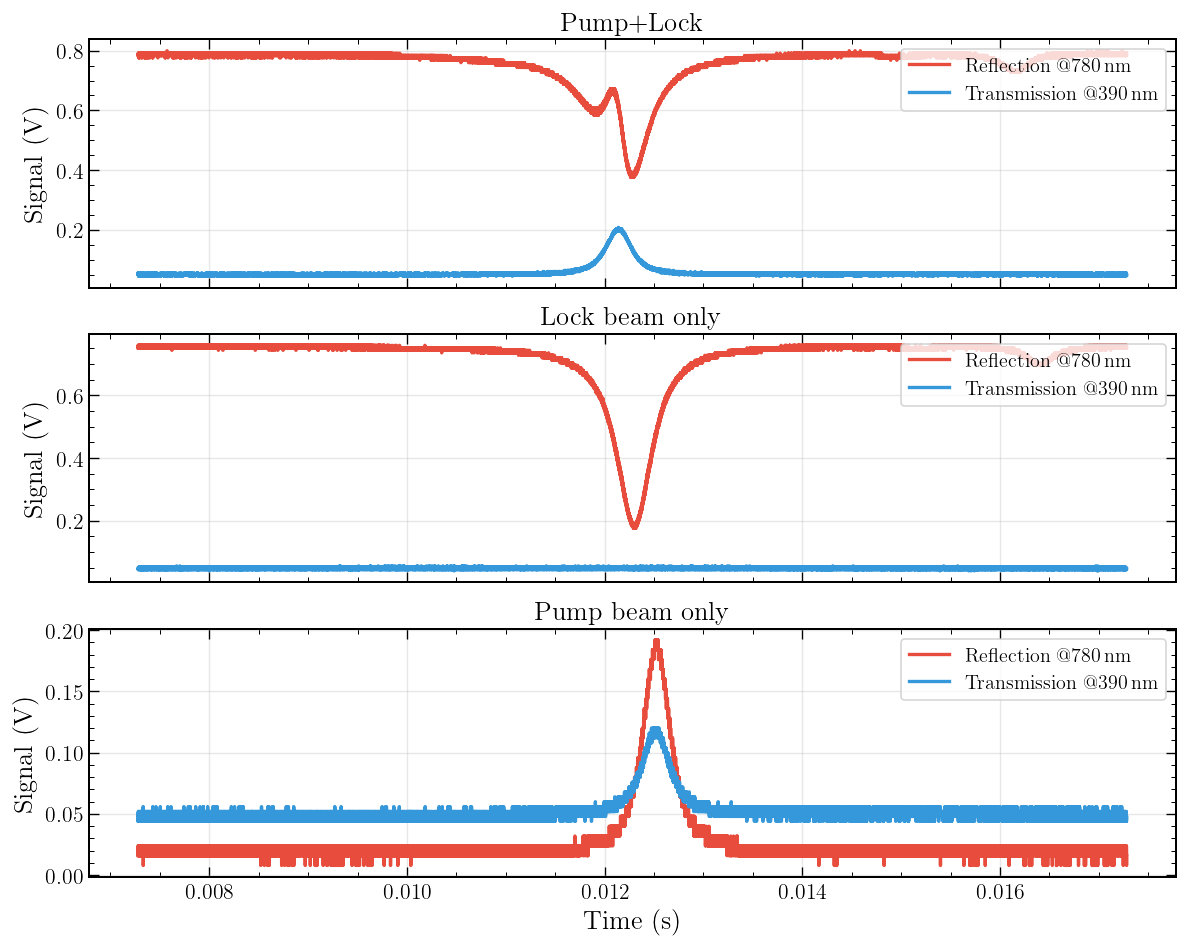

In [33]:
# List all files in the folder
path_folder_data = r"./data/oscilloscope/scope_acq_2026_05_12__07_45_12/"

# name1 = "2026_05_12__09_09_43__oscilloscope_trace.h5"
# name2 = "2026_05_12__09_10_28__oscilloscope_trace.h5"

name1 = "2026_05_12__09_18_57__oscilloscope_trace.h5"
name2 = "2026_05_12__09_20_03__oscilloscope_trace.h5"
name3 = "2026_05_12__09_41_35__oscilloscope_trace.h5"

# name1 = "2026_05_12__09_48_41__oscilloscope_trace.h5"
# name2 = "2026_05_12__09_48_07__oscilloscope_trace.h5"
# name3 = "2026_05_12__09_49_16__oscilloscope_trace.h5"

# subplot titles
subplot_titles = [
    "Pump+Lock",
    "Lock beam only",
    "Pump beam only",
]

name_exp = 'oscilloscope_trace'

aqm = AcquisitionAnalysisManager(
    os.path.join(path_folder_data, name_exp)
)

# files to compare
file_names = [name1, name2, name3]

# custom labels
label_map = {
    "CH1": r"Reflection $@780\,\mathrm{nm}$",
    "CH2": r"Ramp",
    "CH3": r"Transmission $@390\,\mathrm{nm}$",
}

# Plot
set_plot_style()

fig, axs = plt.subplots(
    3, 1,
    figsize=(10, 8),
    sharex=True
)

for ax, name, subplot_title  in zip(axs, file_names, subplot_titles):

    full_path = os.path.join(
        path_folder_data,
        name_exp,
        name
    )

    aqm.analysis_cell(filename=full_path)
    data = aqm.data

    # find channels present in this file
    channels = []
    for ch in ["CH1", "CH2", "CH3", "CH4"]:
        if f"{ch}_x" in data and f"{ch}_y" in data:
            channels.append(ch)

    for ch in channels:

        x = data[f"{ch}_x"]
        y = data[f"{ch}_y"]

        # comment ramp out but keep code
        if ch == "CH2":
            continue

        # fallback to channel name if not defined
        label = label_map.get(ch, ch)

        ax.plot(x, y, label=label)

    ax.set_ylabel("Signal (V)")
    ax.set_title(subplot_title)
    ax.grid()

    legend = ax.legend(loc="upper right", frameon=True)
    legend.get_frame().set_facecolor('white')

axs[-1].set_xlabel("Time (s)")

plt.tight_layout()
plt.show()

INFO:2026_05_12__09_20_03__oscilloscope_trace


INFO:2026_05_12__09_41_35__oscilloscope_trace


INFO:2026_05_12__09_18_57__oscilloscope_trace


Lock only: 37501 points
Pump only: 37500 points
Pump + Lock: 37501 points


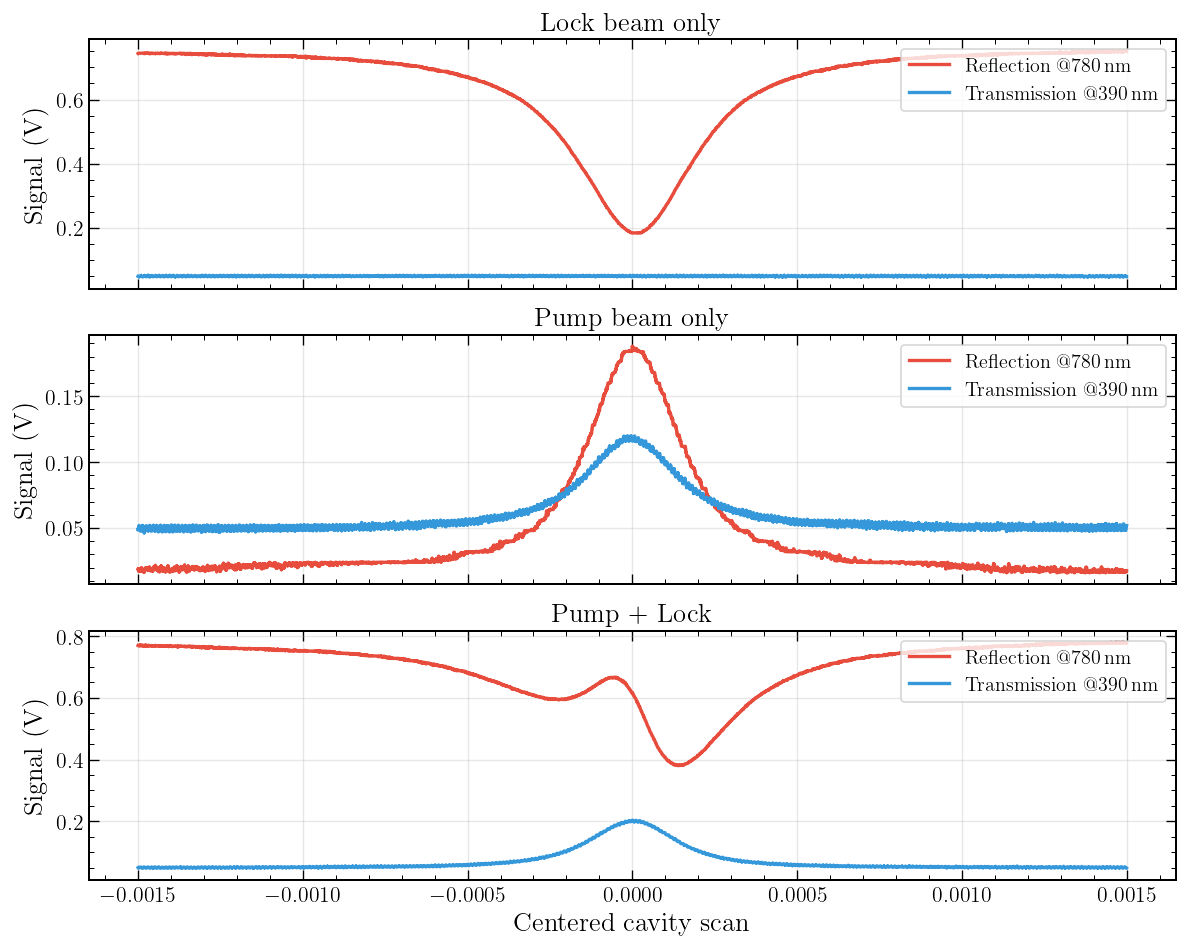

In [62]:
# --- Simple comparison: lock only, pump only, and Pump+Lock ---

# files
name_lock = name2
name_pump = name3
name_both = name1

window_s = 3e-3
half_window = window_s / 2

smooth_N = 25

def smooth(y, N):
    kernel = np.ones(N) / N
    return np.convolve(y, kernel, mode="same")


# -------------------------
# load lock only
# -------------------------

aqm.analysis_cell(filename=os.path.join(path_folder_data, name_exp, name_lock))
data_lock = aqm.data

x_lock = np.array(data_lock["CH1_x"])  # time axis for lock only
r_lock = smooth(np.array(data_lock["CH1_y"]), smooth_N)  # smooth reflection to get better estimate of center
shg_lock = smooth(np.array(data_lock["CH3_y"]), smooth_N)  # smooth SHG to get better estimate of center

t0_lock = x_lock[np.argmin(r_lock)]

x_lock = x_lock - t0_lock


# -------------------------
# load pump only
# -------------------------

aqm.analysis_cell(filename=os.path.join(path_folder_data, name_exp, name_pump))
data_pump = aqm.data

x_pump = np.array(data_pump["CH1_x"])
r_pump = smooth(np.array(data_pump["CH1_y"]), smooth_N)
shg_pump = smooth(np.array(data_pump["CH3_y"]), smooth_N)

t0_pump = x_pump[np.argmax(r_pump)]

x_pump = x_pump - t0_pump


# -------------------------
# load pump + lock
# -------------------------

aqm.analysis_cell(filename=os.path.join(path_folder_data, name_exp, name_both))
data_both = aqm.data

x_both = np.array(data_both["CH1_x"])
r_both = smooth(np.array(data_both["CH1_y"]), smooth_N)
shg_both = smooth(np.array(data_both["CH3_y"]), smooth_N)

# center on SHG peak
t0_both = x_both[np.argmax(shg_both)]

x_both = x_both - t0_both


# -------------------------
# crop same window
# -------------------------

mask_lock = np.abs(x_lock) < half_window
mask_pump = np.abs(x_pump) < half_window
mask_both = np.abs(x_both) < half_window

x_lock_plot = x_lock[mask_lock]
r_lock_plot = r_lock[mask_lock]
shg_lock_plot = shg_lock[mask_lock]
print(f"Lock only: {len(x_lock_plot)} points")

x_pump_plot = x_pump[mask_pump]
r_pump_plot = r_pump[mask_pump]
shg_pump_plot = shg_pump[mask_pump]
print(f"Pump only: {len(x_pump_plot)} points")

x_both_plot = x_both[mask_both]
r_both_plot = r_both[mask_both]
shg_both_plot = shg_both[mask_both]
print(f"Pump + Lock: {len(x_both_plot)} points")

# -------------------------
# numerical sum of reflection features
# -------------------------

# try small shifts by hand
pump_shift = -0.45e-3   # seconds, adjust by eye

r_lock_interp = np.interp(x_both_plot, x_lock_plot, r_lock_plot)
r_pump_interp = np.interp(x_both_plot, x_pump_plot + pump_shift, r_pump_plot)

n_edge = 100

r_lock_base = np.mean(np.r_[r_lock_plot[:n_edge], r_lock_plot[-n_edge:]])
r_pump_base = np.mean(np.r_[r_pump_plot[:n_edge], r_pump_plot[-n_edge:]])
r_both_base = np.mean(np.r_[r_both_plot[:n_edge], r_both_plot[-n_edge:]])

r_sum = r_both_base + (r_lock - r_lock_base) + (r_pump - r_pump_base)

# -------------------------
# plot
# -------------------------

set_plot_style()

fig, axs = plt.subplots(
    3, 1,
    figsize=(10, 8),
    sharex=True
)

# lock only
axs[0].plot(x_lock_plot, r_lock_plot, label=r"Reflection $@780\,\mathrm{nm}$")
axs[0].plot(x_lock_plot, shg_lock_plot, label=r"Transmission $@390\,\mathrm{nm}$")
axs[0].set_title("Lock beam only")
axs[0].set_ylabel("Signal (V)")
axs[0].grid()
axs[0].legend(loc="upper right", frameon=True)

# pump only
axs[1].plot(x_pump_plot, r_pump_plot, label=r"Reflection $@780\,\mathrm{nm}$")
axs[1].plot(x_pump_plot, shg_pump_plot, label=r"Transmission $@390\,\mathrm{nm}$")
axs[1].set_title("Pump beam only")
axs[1].set_ylabel("Signal (V)")
axs[1].grid()
axs[1].legend(loc="upper right", frameon=True)

# pump + lock comparison
axs[2].plot(
    x_both_plot,
    r_both_plot,
    linewidth=2,
    label=r"Reflection $@780\,\mathrm{nm}$"
)

axs[2].plot(
    x_both_plot,
    shg_both_plot,
    linewidth=2,
    label=r"Transmission $@390\,\mathrm{nm}$"
)

# axs[2].plot(
#     x_both_plot,
#     r_sum,
#     "--",
#     color="lightcoral",
#     linewidth=2,
#     label="Lock only + Pump only reflection"
# )

axs[2].set_title("Pump + Lock")
axs[2].set_ylabel("Signal (V)")
axs[2].set_xlabel("Centered cavity scan")
axs[2].grid()
axs[2].legend(loc="upper right", frameon=True)

plt.tight_layout()
plt.show()

# Finesse measurements from resonances

### Load data

In [21]:
path_folder_data = r"./data/oscilloscope/scope_acq_2026_05_13__08_25_49/"
folder_data_files = os.listdir(path_folder_data)
print(folder_data_files)
# fine data scan :
name_exp = 'oscilloscope_trace'
name = "2026_05_13__08_25_50__oscilloscope_trace.h5"
full_path = os.path.join(path_folder_data, name_exp, name)
aqm = AcquisitionAnalysisManager( os.path.join(path_folder_data, name_exp))
aqm.analysis_cell(filename=full_path)

data = aqm.data
print(data)

['oscilloscope_trace', 'temp.json']


INFO:2026_05_13__08_25_50__oscilloscope_trace


AnalysisData (rw) (not saved): 
 {
    "CH1_pt_off" (r): "0.000e+00 (type : float64)",
    "CH1_x" (r): "shape: (125000,) (type: ndarray)",
    "CH1_xincr" (r): "1.600e-06 (type : float64)",
    "CH1_xzero" (r): "-0.100 (type : float64)",
    "CH1_y" (r): "shape: (125000,) (type: ndarray)",
    "CH1_y_raw" (r): "shape: (125000,) (type: ndarray)",
    "CH1_ymult" (r): "8.000e-03 (type : float64)",
    "CH1_yoff" (r): "-100.000 (type : float64)",
    "CH1_yzero" (r): "0.000e+00 (type : float64)",
    "CH2_pt_off" (r): "0.000e+00 (type : float64)",
    "CH2_x" (r): "shape: (125000,) (type: ndarray)",
    "CH2_xincr" (r): "1.600e-06 (type : float64)",
    "CH2_xzero" (r): "-0.100 (type : float64)",
    "CH2_y" (r): "shape: (125000,) (type: ndarray)",
    "CH2_y_raw" (r): "shape: (125000,) (type: ndarray)",
    "CH2_ymult" (r): "4.000e-02 (type : float64)",
    "CH2_yoff" (r): "-69.000 (type : float64)",
    "CH2_yzero" (r): "0.000e+00 (type : float64)",
    "CH3_pt_off" (r): "0.000e+00 (ty

In [22]:
c = constants.c  # speed of light in m/s
L_cav = 500e-3          # m, cavity length
FSR = c / L_cav         # Hz

### Set signals variables

In [23]:
time = np.array(data["CH1_x"])

lock = np.array(data["CH1_y"])   # CH1: lock beam
ramp = np.array(data["CH2_y"])   # CH2: ramp
pump = np.array(data["CH3_y"])   # CH3: pump

In [62]:
# signal = -lock        # change to -pump if you want pump peaks instead
signal = -pump
signal = signal - np.mean(signal)
ramp = ramp - np.mean(ramp)


In [63]:
def lorentzian(x, A, x0, gamma, C):
    return A * (0.5 * gamma)**2 / ((x - x0)**2 + (0.5 * gamma)**2) + C


### Find the linear part of the ramp

In [64]:
max_ramp = np.max(ramp)
min_ramp = np.min(ramp)

threshold_low = min_ramp + 0.05 * (max_ramp - min_ramp)
threshold_high = max_ramp - 0.05 * (max_ramp - min_ramp)
linear_mask = (ramp > threshold_low) & (ramp < threshold_high)

segments = []
min_segment_length = 1000
in_segment = False

for i, val in enumerate(linear_mask):
    if val and not in_segment:
        start_idx = i
        in_segment = True
    elif (not val or i == len(linear_mask)-1) and in_segment:
        end_idx = i
        in_segment = False
        if end_idx - start_idx >= min_segment_length:
            segments.append((start_idx, end_idx))

print(f"Found {len(segments)} linear windows.")

Found 9 linear windows.


### Plot raw data with peaks and ramp segment highlighted

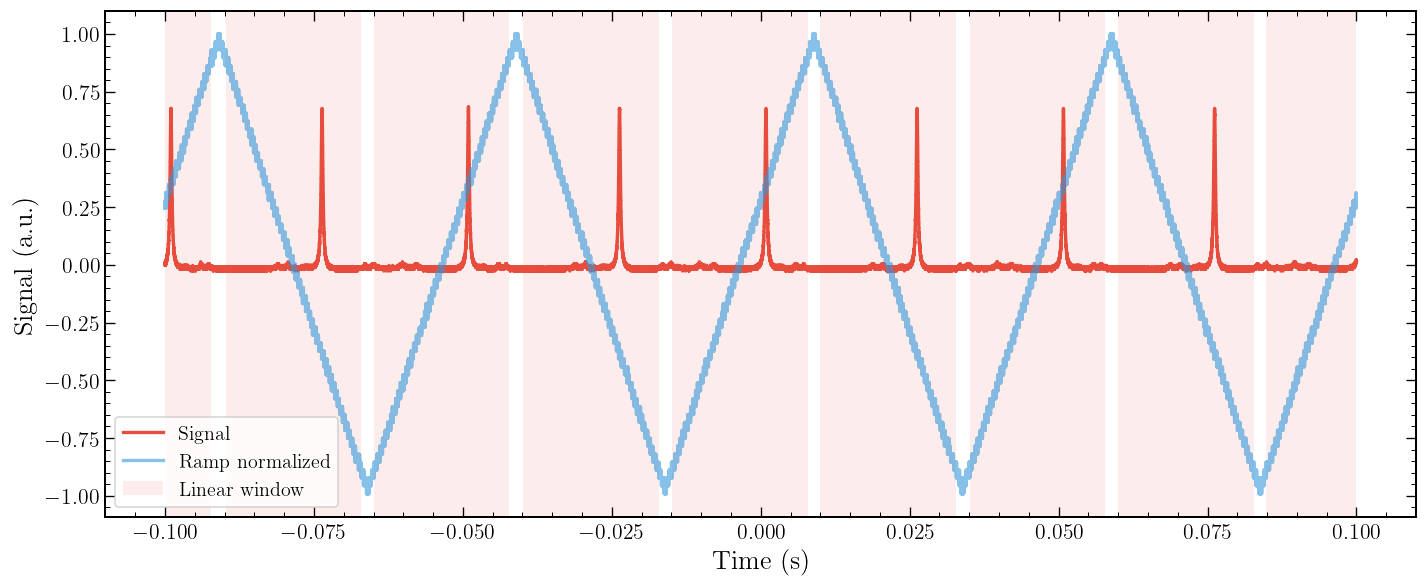

In [65]:
plt.figure(figsize=(12, 5))
ramp_norm = ramp / np.max(np.abs(ramp))

plt.plot(time, signal, label="Signal")
plt.plot(time, ramp_norm, label="Ramp normalized", alpha=0.6)

for i, (start_idx, end_idx) in enumerate(segments):
    plt.axvspan(time[start_idx], time[end_idx], alpha=0.1,
                label="Linear window" if i == 0 else None)
    
plt.xlabel("Time (s)")
plt.ylabel("Signal (a.u.)")
plt.legend()
plt.tight_layout()
plt.show()


### Find peaks and fit Lorentzian

In [66]:
peak_fits = []
all_peaks = []

N = 150

# first pass: find all peaks
for window_id, (start_idx, end_idx) in enumerate(segments):

    segment_signal = signal[start_idx:end_idx]

    peaks, _ = find_peaks(
        segment_signal,
        height=0.05,
        prominence=0.05,
        distance=200
    )

    print(f"Window {window_id}: {len(peaks)} peaks")

    for peak in peaks:
        all_peaks.append((start_idx + peak, window_id))

print(f"Total peaks found: {len(all_peaks)}")

# calibration from all detected peaks
peak_times = np.array([time[idx] for idx, window_id in all_peaks])
peak_times = np.sort(peak_times)

time_per_FSR = np.median(np.diff(peak_times))
Hz_per_sec = FSR / time_per_FSR

print(f"time_per_FSR = {time_per_FSR:.3e} s")
print(f"Hz_per_sec   = {Hz_per_sec:.3e} Hz/s")

# second pass: fit all peaks
for idx, window_id in all_peaks:

    if idx - N < 0 or idx + N >= len(signal):
        continue

    xdata = time[idx-N:idx+N]
    ydata = signal[idx-N:idx+N]

    A_guess = np.max(ydata) - np.min(ydata)
    x0_guess = time[idx]
    gamma_guess = 20 * (time[1] - time[0])
    C_guess = np.min(ydata)

    p0 = [A_guess, x0_guess, gamma_guess, C_guess]


    popt, pcov = curve_fit(lorentzian, xdata, ydata, p0=p0)

    A_fit, x0_fit, gamma_fit, C_fit = popt

    gamma_freq = abs(gamma_fit * Hz_per_sec)
    finesse = FSR / gamma_freq

    peak_fits.append({
        "A": A_fit,
        "x0": x0_fit,
        "gamma_time": gamma_fit,
        "gamma_freq": gamma_freq,
        "finesse": finesse,
        "C": C_fit,
        "window_id": window_id,
        "time_per_FSR": time_per_FSR
    })

print(f"Fitted {len(peak_fits)} peaks")

Window 0: 1 peaks
Window 1: 1 peaks
Window 2: 1 peaks
Window 3: 1 peaks
Window 4: 1 peaks
Window 5: 1 peaks
Window 6: 1 peaks
Window 7: 1 peaks
Window 8: 0 peaks
Total peaks found: 8
time_per_FSR = 2.536e-02 s
Hz_per_sec   = 2.365e+10 Hz/s
Fitted 8 peaks


### Plot fitted curves

Fitted 8 peaks across 9 windows.


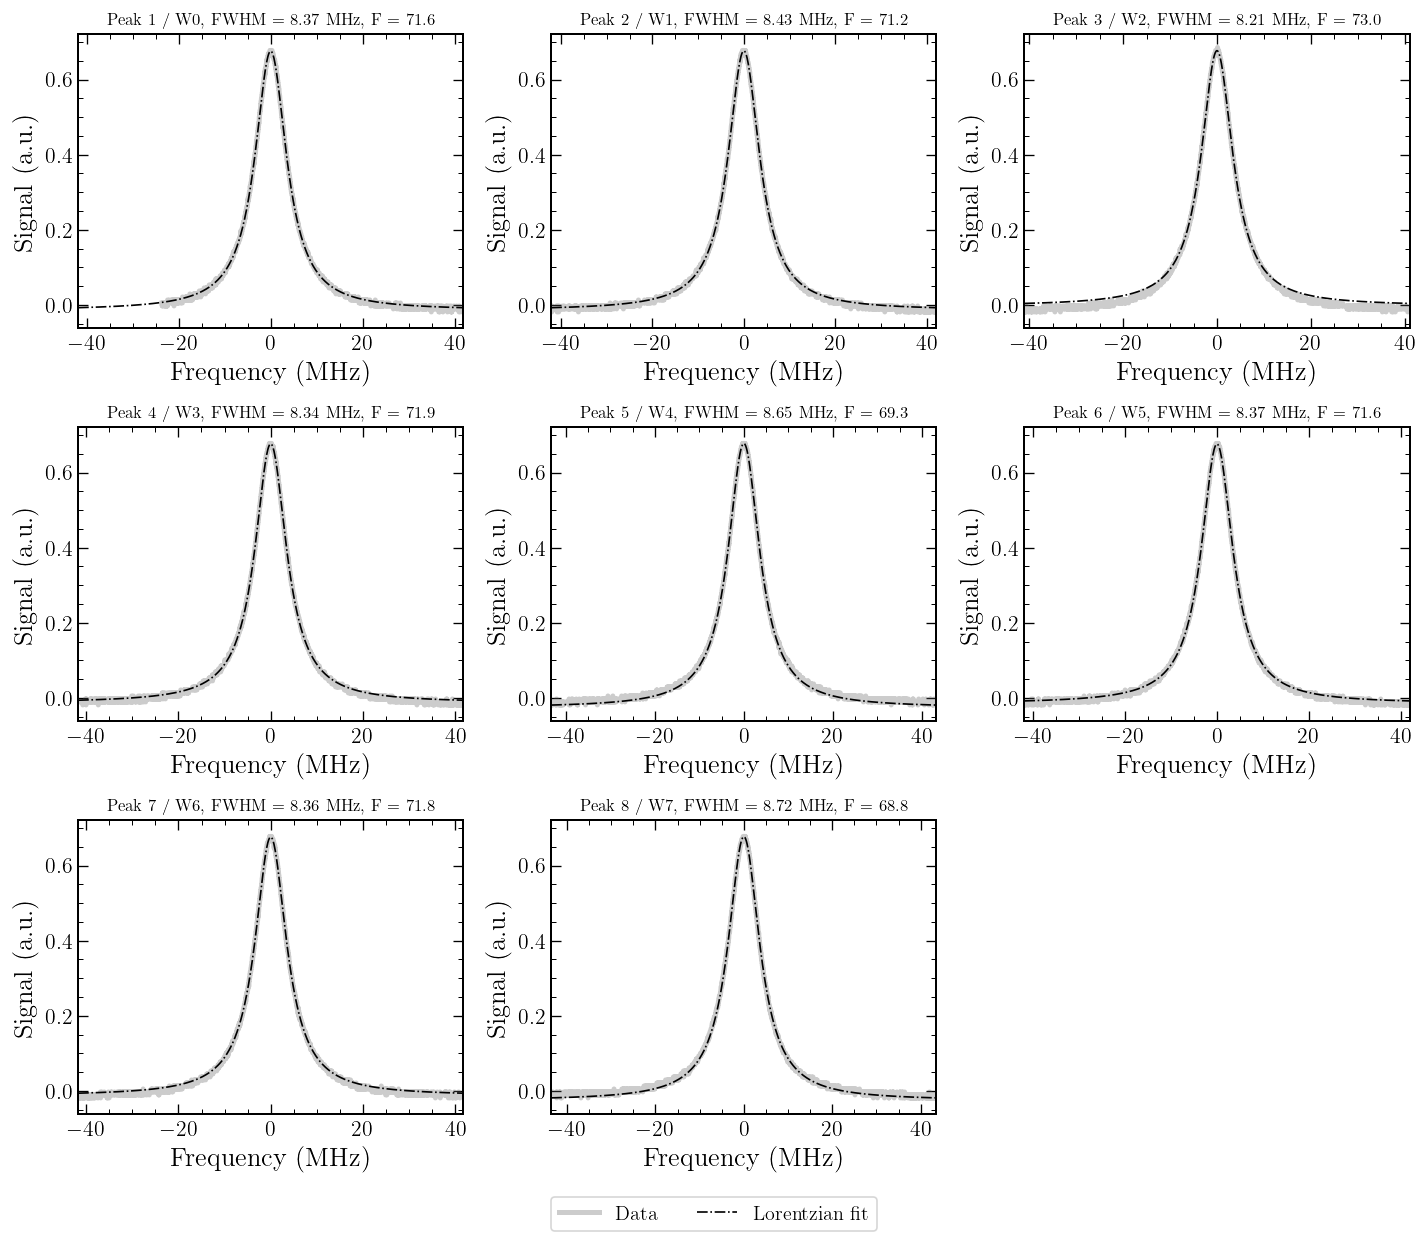

In [82]:
num_peaks = len(peak_fits)
print(f"Fitted {num_peaks} peaks across {len(segments)} windows.")

cols = int(np.ceil(np.sqrt(num_peaks)))
rows = int(np.ceil(num_peaks / cols))

fig, axes = plt.subplots(
    rows,
    cols,
    figsize=(4*cols, 3.5*rows)
)

axes = np.array(axes).reshape(-1)

for i, pf in enumerate(peak_fits):

    ax = axes[i]

    A = pf["A"]
    x0 = pf["x0"]
    gamma_time = pf["gamma_time"]
    gamma_freq = pf["gamma_freq"]
    finesse = pf["finesse"]
    C = pf["C"]

    time_per_FSR = pf["time_per_FSR"]
    Hz_per_sec = FSR / time_per_FSR

    t_fit = np.linspace(
        x0 - 5*abs(gamma_time),
        x0 + 5*abs(gamma_time),
        1000
    )

    y_fit = lorentzian(t_fit, A, x0, gamma_time, C)

    freq_fit = (t_fit - x0) * Hz_per_sec / 1e6
    freq_data = (time - x0) * Hz_per_sec / 1e6

    ax.plot(freq_data, signal, color="0.35", alpha=0.3, lw=3.0, label="Data")
    ax.plot(freq_fit, y_fit, color="k", linestyle="-.", lw=1.0, label="Lorentzian fit")

    ax.set_xlim(freq_fit[0], freq_fit[-1])

    ax.set_title(
        f"Peak {i+1} / W{pf['window_id']}, "
        f"FWHM = {gamma_freq/1e6:.2f} MHz, "
        f"F = {finesse:.1f}",
        fontsize=10
    )

    ax.set_xlabel("Frequency (MHz)")
    ax.set_ylabel("Signal (a.u.)")

# hide unused axes
for j in range(i+1, len(axes)):
    axes[j].axis("off")

# common legend
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=2,
    frameon=True,
    bbox_to_anchor=(0.5, 0.01)
)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

### Summary

In [68]:
for i, pf in enumerate(peak_fits):
    print(
        f"Peak {i+1}: "
        f"FWHM = {pf['gamma_freq']/1e6:.3f} MHz, "
        f"Finesse = {pf['finesse']:.1f}"
    )

# Average FWHM and Finesse
gamma_freqs = np.array([pf["gamma_freq"] for pf in peak_fits])
finesses = np.array([pf["finesse"] for pf in peak_fits])
print(f"Average FWHM = {np.mean(gamma_freqs)/1e6:.3f} MHz")
print(f"Average Finesse = {np.mean(finesses):.1f}")

Peak 1: FWHM = 8.374 MHz, Finesse = 71.6
Peak 2: FWHM = 8.426 MHz, Finesse = 71.2
Peak 3: FWHM = 8.209 MHz, Finesse = 73.0
Peak 4: FWHM = 8.345 MHz, Finesse = 71.9
Peak 5: FWHM = 8.651 MHz, Finesse = 69.3
Peak 6: FWHM = 8.371 MHz, Finesse = 71.6
Peak 7: FWHM = 8.356 MHz, Finesse = 71.8
Peak 8: FWHM = 8.717 MHz, Finesse = 68.8
Average FWHM = 8.431 MHz
Average Finesse = 71.1
